# EDA Census Dataset

# Introduction

This notebook profiles the raw Census ACS county-level data (2023 5-year estimates) —
3,222 counties × 2 features (`poverty_count`, `median_income`) — before joining it to
CDC PLACES, USDA FARA, and CHR&R on the 5-digit county FIPS code. Unlike the other
source notebooks, this dataset is already at the county grain, so there is no
tract-to-county aggregation step. The work here is smaller but still real: fixing the
FIPS dtype so the join key matches the other sources, deciding what to do with the two
missing `median_income` values, and checking whether the extreme `poverty_count`
values are data errors or just large counties.

**What this notebook does:**
1. Load the raw CSV and inspect structure, dtypes, and the FIPS join key
2. Fix `fips` to a zero-padded 5-digit string (matches `CountyFIPS`/`GEOID` in the other sources)
3. Check for duplicate counties and missing values, and decide how to handle them
4. Check for outliers in `poverty_count` and `median_income`
5. Export the cleaned table for the merge notebook

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Read the data

In [3]:
base_path = Path.cwd().parents[1]  # Get the parent directory of the current working directory

data_path = base_path / "data" / "raw" / "3_Census_acs_Bureau_county_2023.csv"

df = pd.read_csv(data_path, dtype={"fips": str})
df["fips"] = df["fips"].str.zfill(5)

print(f"Data loaded successfully: {df.shape[0]:,} rows x {df.shape[1]} columns")

Data loaded successfully: 3,222 rows x 3 columns


**Why `dtype=str` + `zfill(5)`:** the raw CSV stores `fips` as a bare integer, which drops
the leading zero for states 01–09 (Alabama's Autauga County reads as `1001` instead of
`01001`). Every other source in this project joins on a zero-padded 5-digit
`CountyFIPS`/`GEOID`, so this is fixed at load time rather than left for the merge
notebook to catch.

# Preview the data

In [4]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")

print("\nData types:")
display(df.dtypes.to_frame(name="data_type"))

print("\nFirst 5 rows:")
display(df.head())

print("\nSummary statistics:")
display(df.describe())

Number of rows: 3,222
Number of columns: 3

Data types:


,data_type
fips,object
poverty_count,int64
median_income,float64



First 5 rows:


,fips,poverty_count,median_income
0,01001,6275,69841.0
1,01003,24819,75019.0
2,01005,4746,44290.0
3,01007,4258,51215.0
4,01009,8269,61096.0



Summary statistics:


,poverty_count,median_income
count,3.222000e+03,3220.000000
mean,1.295179e+04,65046.649068
std,4.284887e+04,18388.683350
min,3.000000e+00,16170.000000
25%,1.517750e+03,54113.250000
50%,3.778500e+03,63161.500000
75%,9.779000e+03,73216.250000
max,1.322476e+06,178707.000000


## Check duplicate FIPS

`fips` is the county join key, so it must be unique — a duplicate would mean the same
county appears twice and would fan out rows on the merge.

In [5]:
dup_fips = df["fips"].duplicated().sum()
print(f"Duplicate FIPS codes: {dup_fips}")
print(f"Unique counties: {df['fips'].nunique():,} of {len(df):,} rows")

Duplicate FIPS codes: 0
Unique counties: 3,222 of 3,222 rows


## Check missing values

In [6]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().mean() * 100).round(3)
})
display(missing)

,Missing Count,Missing %
fips,0,0.000
poverty_count,0,0.000
median_income,2,0.062


Only `median_income` has missing values — 2 rows, 0.06% of the data. That's too small to
justify imputation logic; I drop the 2 rows rather than guess at a county's income.

In [14]:
before = len(df)
df = df.dropna(subset=["median_income"])
print(f"Dropped {before - len(df)} rows with missing median_income")
print(f"Remaining rows: {len(df):,}")

Dropped 2 rows with missing median_income
Remaining rows: 3,220


## Check for outliers

`describe()` on the raw data showed `poverty_count` ranging from 3 to 1.32M against a
75th percentile of ~9,800 — a heavy right skew. That's expected for a count variable
across counties that range from a few hundred people to Los Angeles County's ~10M, not
necessarily a data error, but worth confirming visually before it feeds a model.

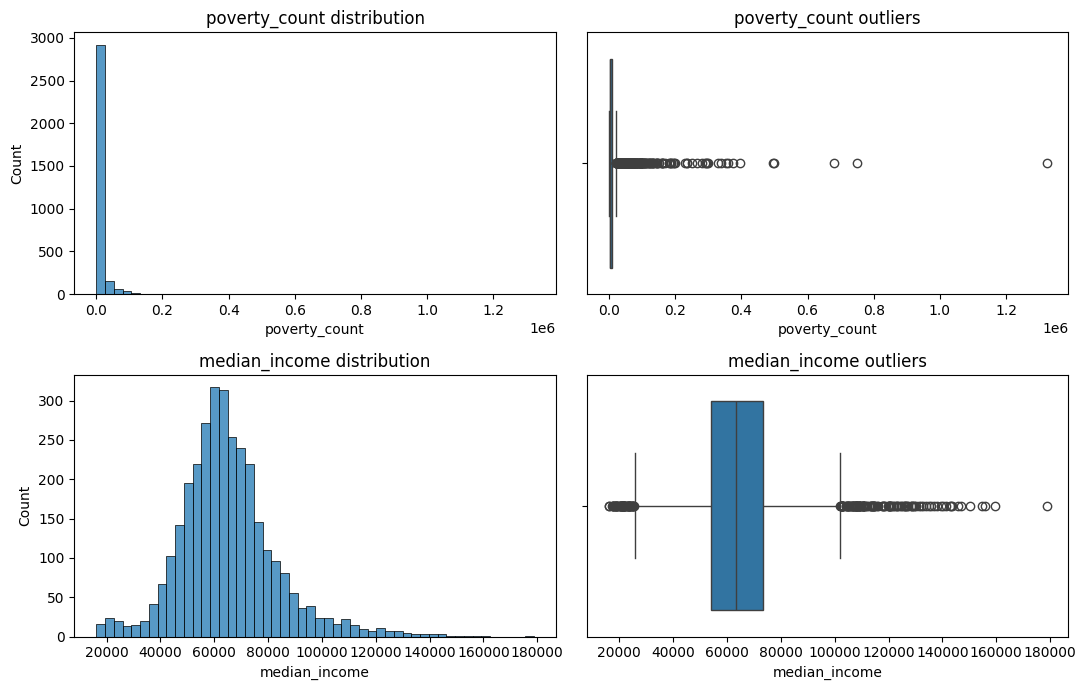

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

sns.histplot(df["poverty_count"], bins=50, ax=axes[0, 0])
axes[0, 0].set_title("poverty_count distribution")

sns.boxplot(x=df["poverty_count"], ax=axes[0, 1])
axes[0, 1].set_title("poverty_count outliers")

sns.histplot(df["median_income"], bins=50, ax=axes[1, 0])
axes[1, 0].set_title("median_income distribution")

sns.boxplot(x=df["median_income"], ax=axes[1, 1])
axes[1, 1].set_title("median_income outliers")

plt.tight_layout()
plt.show()

poverty_count has a long right tail — most counties have small values, but a few very large counties pull the distribution far to the right. This makes sense: poverty_count is a raw count, so it naturally scales with how many people live in the county, not a sign of bad data. median_income looks roughly normal, with reasonable values ranging from about $16,170 to $178,707. We don't drop any rows here. Since poverty_count is skewed, it will likely need to be turned into a rate (poverty_count divided by population) or log-transformed before modeling — but that step belongs in feature engineering, not in this EDA.


## Correlation

Just the two numeric features — a quick check for redundancy before either enters the
model.

,poverty_count,median_income
poverty_count,1.000000,0.156772
median_income,0.156772,1.000000


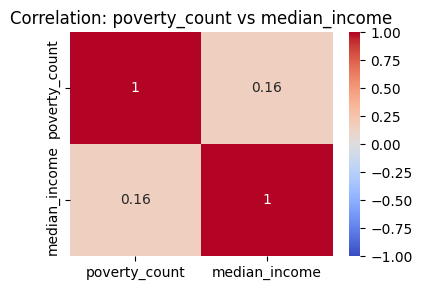

In [8]:
corr = df[["poverty_count", "median_income"]].corr()
display(corr)

plt.figure(figsize=(4, 3))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation: poverty_count vs median_income")
plt.tight_layout()
plt.show()

The observed positive correlation (r ≈ 0.16) between poverty_count and median_income should not be interpreted as evidence of a substantive relationship between poverty and income at the county level. Because poverty_count is an absolute count rather than a normalized rate, it is inherently confounded with county population size: larger, more populous counties tend to exhibit both higher raw poverty counts and higher median incomes due to metropolitan economic effects. As such, this correlation reflects a population-scale artifact rather than a meaningful association between poverty and income. To address this limitation, we propose converting poverty_count into a population-adjusted poverty rate prior to model inclusion, using a population denominator to be obtained from an auxiliary data source. This transformation will be incorporated into the feature engineering stage of the analysis pipeline.

# Findings and Output

| Check | Result | Decision |
|---|---|---|
| Raw shape | 3,222 counties × 3 columns (`fips`, `poverty_count`, `median_income`) | Census ACS 2023 5-year estimates, already at county grain — no aggregation needed |
| FIPS format | Raw `fips` loaded as int, dropping leading zeros for states 01–09 | Loaded as `dtype=str` + `zfill(5)` at read time to match `CountyFIPS`/`GEOID` used by the other sources |
| Duplicate FIPS | 0 duplicates, 3,222 unique counties | No action |
| Missing values | `median_income` missing in 2 rows (0.06%); | Dropped the 2 rows — too small a fraction to justify imputation |
| Outliers | `poverty_count` heavily right-skewed (max ~1.32M, LA County); `median_income` roughly normal, plausible range \$16,170–\$178,707 | Kept as-is; flagged `poverty_count` for a rate conversion or log transform in feature engineering |
| Correlation | r ≈ 0.16 between `poverty_count` and `median_income` | Positive sign is a population-size artifact (raw count vs. income), not a poverty–income relationship — suggest convert `poverty_count` to a rate before modeling |
| Cleaned shape | 3,220 rows × 3 columns, 0 blanks | Ready for export |
| Output file | `data/processed/Census_ACS_County_2023.csv` | County ACS input to the merge notebook, joined on `fips`/`CountyFIPS` |

**Next steps.** Join to CDC PLACES, USDA FARA, and CHR&R on the 5-digit FIPS in the
merge notebook. Before modeling, convert `poverty_count` to a poverty rate using a
population denominator (from CHR&R or another source) rather than using the raw count.

In [9]:
out_path = base_path / "data" / "processed" / "Census_ACS_County_2023.csv"
df.to_csv(out_path, index=False)
print("Saved:", df.shape, "->", out_path)

Saved: (3222, 3) -> /Users/nancywalker/Documents/University_SanDiego/ADS-599-CapstoneProject/ADS599_Capstone_Hypertension_Risk_Atlas/data/processed/Census_ACS_County_2023.csv
